## Exploratory data analysis

Establishes the facts every later decision rests on: 1693 training frames and
414 test frames at 720x480, all synthetic renders; every annotated person is
*entirely* outside the frame, 852 behind the left edge and 840 behind the right;
the vertical position of the box barely varies; and the constant-prediction
baseline scores 0.4295 mean IoU, which is the floor any model has to clear.

---

**Provenance.** This is an as-run artifact from the BrabantHack 2026 DEMCON
challenge, preserved with its original outputs so the numbers quoted in
[`docs/experiments.md`](../docs/experiments.md) can be checked against the logs
that produced them. Paths are relative to the original repository layout.

The method it arrived at has since been rewritten as a tested package under
[`src/shadow_detection/`](../src/shadow_detection); run
`shadow-detection train --help` rather than this notebook.


# BrabantHack 26 - Shadow Detection EDA

Goal: fully understand the dataset before writing any model code.

What we need to know:
1. Data structure: image sizes, annotation format, how many samples
2. Bbox geometry: where are the persons relative to the frame, how big are they, which edges
3. Direction distribution: balanced or skewed
4. Shadow characteristics: what do the images actually look like
5. Export summary CSVs for pipeline consumption

In [1]:
import json
import os
from pathlib import Path

import cv2
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

%matplotlib inline
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["figure.dpi"] = 100

In [2]:
# -- Paths (adjust if needed) --
BASE_DIR = Path("../data")
TRAIN_DIR = BASE_DIR / "train_data" / "train_data"
TEST_DIR = BASE_DIR / "test_data" / "test_data"  # adjust if different
SAMPLE_CSV = BASE_DIR / "sample_solution.csv"
OUTPUT_DIR = Path(".")  # save CSVs here

# Auto-detect: list what is actually inside BASE_DIR
print("Contents of data dir:")
for p in sorted(BASE_DIR.iterdir()):
    if p.is_dir():
        children = list(p.iterdir())[:5]
        print(f"  {p.name}/ ({len(list(p.iterdir()))} items)")
        # Check for nested dir
        for c in children:
            if c.is_dir():
                n = len(list(c.iterdir()))
                print(f"    {c.name}/ ({n} items)")
    else:
        print(f"  {p.name} ({p.stat().st_size} bytes)")

Contents of data dir:
  detection-by-shadow.zip (1057597607 bytes)
  submission_example.csv (16405 bytes)
  test_data/ (1 items)
    test_data/ (415 items)
  train_data/ (1 items)
    train_data/ (3386 items)


In [3]:
# Verify paths exist and find the right ones
# Adapt automatically if the nesting is different
if not TRAIN_DIR.exists():
    # Try single-level nesting
    for candidate in [BASE_DIR / "train_data", BASE_DIR / "train"]:
        if candidate.exists() and any(candidate.glob("*.png")):
            TRAIN_DIR = candidate
            break
        elif candidate.exists():
            # Check one level deeper
            for sub in candidate.iterdir():
                if sub.is_dir() and any(sub.glob("*.png")):
                    TRAIN_DIR = sub
                    break

if not TEST_DIR.exists():
    for candidate in [BASE_DIR / "test_data", BASE_DIR / "test"]:
        if candidate.exists() and any(candidate.glob("*.png")):
            TEST_DIR = candidate
            break
        elif candidate.exists():
            for sub in candidate.iterdir():
                if sub.is_dir() and any(sub.glob("*.png")):
                    TEST_DIR = sub
                    break

if not SAMPLE_CSV.exists():
    for candidate in BASE_DIR.rglob("sample_solution.csv"):
        SAMPLE_CSV = candidate
        break

print(f"TRAIN_DIR: {TRAIN_DIR}  exists={TRAIN_DIR.exists()}")
print(f"TEST_DIR:  {TEST_DIR}   exists={TEST_DIR.exists()}")
print(f"SAMPLE_CSV: {SAMPLE_CSV} exists={SAMPLE_CSV.exists()}")

TRAIN_DIR: ../data/train_data/train_data  exists=True
TEST_DIR:  ../data/test_data/test_data   exists=True
SAMPLE_CSV: ../data/sample_solution.csv exists=False


## 1. Raw data inventory

In [4]:
train_pngs = sorted(TRAIN_DIR.glob("*.png"))
train_jsons = sorted(TRAIN_DIR.glob("*.json"))
test_pngs = sorted(TEST_DIR.glob("*.png")) if TEST_DIR.exists() else []
test_jsons = sorted(TEST_DIR.glob("*.json")) if TEST_DIR.exists() else []

print(f"Train images: {len(train_pngs)}")
print(f"Train jsons:  {len(train_jsons)}")
print(f"Test images:  {len(test_pngs)}")
print(f"Test jsons:   {len(test_jsons)}")

# Check 1:1 correspondence
train_img_stems = {p.stem for p in train_pngs}
train_json_stems = {p.stem for p in train_jsons}
missing_json = train_img_stems - train_json_stems
missing_img = train_json_stems - train_img_stems
if missing_json:
    print(f"WARNING: images without json: {missing_json}")
if missing_img:
    print(f"WARNING: jsons without image: {missing_img}")
if not missing_json and not missing_img:
    print("All train images have matching JSON annotations.")

Train images: 1692
Train jsons:  1692
Test images:  414
Test jsons:   0
All train images have matching JSON annotations.


In [5]:
# Look at raw JSON structure of first sample
if train_jsons:
    with open(train_jsons[0]) as f:
        sample_ann = json.load(f)
    print("Raw JSON (first sample):")
    print(json.dumps(sample_ann, indent=2))
    print(f"\nJSON keys: {list(sample_ann.keys())}")
    if "bbox" in sample_ann:
        print(f"bbox keys: {list(sample_ann['bbox'].keys())}")
        print(f"top_left type: {type(sample_ann['bbox']['top_left'])}")
        print(f"top_left value: {sample_ann['bbox']['top_left']}")

Raw JSON (first sample):
{
  "file_name": "image_0",
  "walking_into_frame_bool": 1,
  "bbox": {
    "top_left": [
      -228.87714385986328,
      223.6187400817871
    ],
    "top_right": [
      -110.61487913131714,
      223.6187400817871
    ],
    "bottom_left": [
      -228.87714385986328,
      416.3587894439697
    ],
    "bottom_right": [
      -110.61487913131714,
      416.3587894439697
    ]
  }
}

JSON keys: ['file_name', 'walking_into_frame_bool', 'bbox']
bbox keys: ['top_left', 'top_right', 'bottom_left', 'bottom_right']
top_left type: <class 'list'>
top_left value: [-228.87714385986328, 223.6187400817871]


In [6]:
# Look at sample_solution.csv
if SAMPLE_CSV.exists():
    sample_df = pd.read_csv(SAMPLE_CSV)
    print(f"Sample solution shape: {sample_df.shape}")
    print(f"Columns: {list(sample_df.columns)}")
    print(f"\nFirst 5 rows:")
    display(sample_df.head())
    print(f"\nIndex / row ID info:")
    print(f"  Has index column: {sample_df.index.name}")
    print(f"  dtypes:\n{sample_df.dtypes}")
else:
    print("sample_solution.csv not found")

sample_solution.csv not found


## 2. Image properties

In [7]:
# Check image sizes, channels, dtype for ALL train images
# (fast -- only reads headers for most formats)
img_widths = []
img_heights = []
img_modes = []

for p in train_pngs:
    img = Image.open(p)
    img_widths.append(img.width)
    img_heights.append(img.height)
    img_modes.append(img.mode)

print(f"Image widths:  unique={set(img_widths)}")
print(f"Image heights: unique={set(img_heights)}")
print(f"Image modes:   unique={set(img_modes)}")
print(f"\nAll same size: {len(set(img_widths)) == 1 and len(set(img_heights)) == 1}")
if img_widths:
    IMG_W = img_widths[0]
    IMG_H = img_heights[0]
    print(f"Standard size: {IMG_W} x {IMG_H}")

Image widths:  unique={720}
Image heights: unique={480}
Image modes:   unique={'RGBA'}

All same size: True
Standard size: 720 x 480


In [8]:
# Check test image sizes too
if test_pngs:
    test_sizes = set()
    for p in test_pngs[:20]:  # sample first 20
        img = Image.open(p)
        test_sizes.add((img.width, img.height))
    print(f"Test image sizes (sample): {test_sizes}")

Test image sizes (sample): {(720, 480)}


In [9]:
# Pixel intensity statistics (sample a few images)
sample_indices = np.linspace(0, len(train_pngs)-1, min(20, len(train_pngs)), dtype=int)
mean_vals = []
std_vals = []
for idx in sample_indices:
    arr = np.asarray(Image.open(train_pngs[idx]).convert("RGB")).astype(np.float32) / 255.0
    mean_vals.append(arr.mean(axis=(0,1)))
    std_vals.append(arr.std(axis=(0,1)))

mean_vals = np.array(mean_vals)
std_vals = np.array(std_vals)
print(f"Channel means (R,G,B): {mean_vals.mean(axis=0)}")
print(f"Channel stds  (R,G,B): {std_vals.mean(axis=0)}")
print(f"\nFor reference, ImageNet: mean=[0.485, 0.456, 0.406] std=[0.229, 0.224, 0.225]")

Channel means (R,G,B): [0.4364287  0.43259978 0.41852552]
Channel stds  (R,G,B): [0.1614416  0.17531155 0.23915558]

For reference, ImageNet: mean=[0.485, 0.456, 0.406] std=[0.229, 0.224, 0.225]


## 3. Parse all annotations into a DataFrame

In [10]:
records = []
parse_errors = []

for json_path in train_jsons:
    with open(json_path) as f:
        ann = json.load(f)

    try:
        bbox = ann["bbox"]
        tl = bbox["top_left"]
        tr = bbox["top_right"]
        bl = bbox["bottom_left"]
        br = bbox["bottom_right"]

        # Corners as [x, y] lists
        all_x = [tl[0], tr[0], bl[0], br[0]]
        all_y = [tl[1], tr[1], bl[1], br[1]]

        records.append({
            "stem": ann.get("file_name", json_path.stem),
            "json_path": str(json_path),
            "img_path": str(json_path.with_suffix(".png")),
            "direction": int(ann["walking_into_frame_bool"]),
            # Raw corner coords
            "tl_x": tl[0], "tl_y": tl[1],
            "tr_x": tr[0], "tr_y": tr[1],
            "bl_x": bl[0], "bl_y": bl[1],
            "br_x": br[0], "br_y": br[1],
            # Axis-aligned bbox
            "xmin": min(all_x),
            "ymin": min(all_y),
            "xmax": max(all_x),
            "ymax": max(all_y),
            # Derived
            "bbox_w": max(all_x) - min(all_x),
            "bbox_h": max(all_y) - min(all_y),
            "cx": (min(all_x) + max(all_x)) / 2,
            "cy": (min(all_y) + max(all_y)) / 2,
        })
    except Exception as e:
        parse_errors.append((json_path.name, str(e)))

df = pd.DataFrame(records)
print(f"Parsed {len(df)} annotations, {len(parse_errors)} errors")
if parse_errors:
    print("Parse errors:", parse_errors[:5])
df.head()

Parsed 1692 annotations, 0 errors


,stem,json_path,img_path,direction,tl_x,tl_y,tr_x,tr_y,bl_x,bl_y,br_x,br_y,xmin,ymin,xmax,ymax,bbox_w,bbox_h,cx,cy
0,image_0,../data/train_data/train_data/image_0.json,../data/train_data/train_data/image_0.png,1,-228.877144,223.618740,-110.614879,223.618740,-228.877144,416.358789,-110.614879,416.358789,-228.877144,223.618740,-110.614879,416.358789,118.262265,192.740049,-169.746011,319.988765
1,image_10,../data/train_data/train_data/image_10.json,../data/train_data/train_data/image_10.png,0,-307.385595,215.691074,-243.787758,215.691074,-307.385595,438.103111,-243.787758,438.103111,-307.385595,215.691074,-243.787758,438.103111,63.597836,222.412037,-275.586677,326.897093
2,image_100,../data/train_data/train_data/image_100.json,../data/train_data/train_data/image_100.png,1,-253.668909,215.604729,-174.385954,215.604729,-253.668909,434.196810,-174.385954,434.196810,-253.668909,215.604729,-174.385954,434.196810,79.282955,218.592081,-214.027432,324.900769
3,image_1000,../data/train_data/train_data/image_1000.json,../data/train_data/train_data/image_1000.png,0,-234.063807,227.459578,-138.250784,227.459578,-234.063807,379.189109,-138.250784,379.189109,-234.063807,227.459578,-138.250784,379.189109,95.813023,151.729531,-186.157295,303.324343
4,image_1001,../data/train_data/train_data/image_1001.json,../data/train_data/train_data/image_1001.png,1,-195.748172,225.637964,-87.976198,225.637964,-195.748172,392.705318,-87.976198,392.705318,-195.748172,225.637964,-87.976198,392.705318,107.771974,167.067354,-141.862185,309.171641


In [11]:
# Add normalized coordinates
df["xmin_norm"] = df["xmin"] / IMG_W
df["ymin_norm"] = df["ymin"] / IMG_H
df["xmax_norm"] = df["xmax"] / IMG_W
df["ymax_norm"] = df["ymax"] / IMG_H
df["cx_norm"] = df["cx"] / IMG_W
df["cy_norm"] = df["cy"] / IMG_H
df["bbox_w_norm"] = df["bbox_w"] / IMG_W
df["bbox_h_norm"] = df["bbox_h"] / IMG_H

print("Normalized coordinate ranges:")
for col in ["xmin_norm", "ymin_norm", "xmax_norm", "ymax_norm"]:
    print(f"  {col}: [{df[col].min():.3f}, {df[col].max():.3f}]  mean={df[col].mean():.3f}")

Normalized coordinate ranges:
  xmin_norm: [-0.499, 1.296]  mean=0.422
  ymin_norm: [0.441, 0.480]  mean=0.464
  xmax_norm: [-0.351, 1.443]  mean=0.534
  ymax_norm: [0.720, 0.968]  mean=0.825


## 4. Bounding box geometry analysis

In [12]:
print("=== Pixel-space bbox statistics ===")
for col in ["xmin", "ymin", "xmax", "ymax", "bbox_w", "bbox_h", "cx", "cy"]:
    s = df[col]
    print(f"  {col:8s}: min={s.min():8.1f}  p25={s.quantile(0.25):8.1f}  "
          f"median={s.median():8.1f}  p75={s.quantile(0.75):8.1f}  max={s.max():8.1f}  "
          f"std={s.std():7.1f}")

=== Pixel-space bbox statistics ===
  xmin    : min=  -359.1  p25=  -216.4  median=  -135.9  p75=   831.6  max=   932.9  std=  529.5
  ymin    : min=   211.9  p25=   220.4  median=   223.5  p75=   225.8  max=   230.3  std=    3.9
  xmax    : min=  -252.9  p25=  -137.0  median=   -83.1  p75=   912.6  max=  1038.8  std=  529.5
  ymax    : min=   345.6  p25=   368.3  median=   392.7  p75=   421.8  max=   464.4  std=   31.5
  bbox_w  : min=    26.8  p25=    57.2  median=    78.6  p75=   103.0  max=   157.2  std=   29.9
  bbox_h  : min=   116.5  p25=   142.8  median=   169.6  p75=   202.4  max=   246.9  std=   34.7
  cx      : min=  -289.4  p25=  -175.5  median=  -117.0  p75=   871.6  max=   973.2  std=  529.3
  cy      : min=   286.0  p25=   297.0  median=   308.0  p75=   321.0  max=   343.0  std=   14.3


In [13]:
# Are bounding boxes axis-aligned rectangles? (all 4 corners form a rectangle?)
# Check: tl_y == tr_y, bl_y == br_y, tl_x == bl_x, tr_x == br_x
is_rect = (
    np.isclose(df["tl_y"], df["tr_y"]) &
    np.isclose(df["bl_y"], df["br_y"]) &
    np.isclose(df["tl_x"], df["bl_x"]) &
    np.isclose(df["tr_x"], df["br_x"])
)
print(f"Axis-aligned rectangles: {is_rect.sum()}/{len(df)} ({is_rect.mean()*100:.1f}%)")
if not is_rect.all():
    print("Some bboxes are NOT axis-aligned! Check for rotated boxes.")
    print(df[~is_rect][["stem", "tl_x", "tl_y", "tr_x", "tr_y", "bl_x", "bl_y"]].head())

Axis-aligned rectangles: 1692/1692 (100.0%)


In [14]:
# Which side of the frame is the person on?
def classify_edge(row):
    edges = []
    if row["xmax"] < 0:        edges.append("left")
    if row["xmin"] > IMG_W:    edges.append("right")
    if row["ymax"] < 0:        edges.append("top")
    if row["ymin"] > IMG_H:    edges.append("bottom")
    # Partially off-screen cases
    if not edges:
        if row["xmin"] < 0:    edges.append("partial_left")
        if row["xmax"] > IMG_W: edges.append("partial_right")
        if row["ymin"] < 0:    edges.append("partial_top")
        if row["ymax"] > IMG_H: edges.append("partial_bottom")
    if not edges:
        edges.append("IN_FRAME")  # shouldn't happen per problem description
    return ",".join(edges)

df["edge"] = df.apply(classify_edge, axis=1)
print("Person edge distribution:")
print(df["edge"].value_counts().to_string())
print(f"\nFully off-screen: {(~df['edge'].str.contains('partial|IN_FRAME')).sum()}/{len(df)}")

Person edge distribution:
edge
left     852
right    840

Fully off-screen: 1692/1692


In [15]:
# Aspect ratio
df["aspect_ratio"] = df["bbox_h"] / df["bbox_w"].clip(lower=1)
print(f"Aspect ratio (h/w): mean={df['aspect_ratio'].mean():.2f}  "
      f"std={df['aspect_ratio'].std():.2f}  "
      f"min={df['aspect_ratio'].min():.2f}  max={df['aspect_ratio'].max():.2f}")
print(f"\nFor reference: a standing person is typically h/w ~ 2.5-3.5")

Aspect ratio (h/w): mean=2.40  std=0.90  min=1.52  max=4.73

For reference: a standing person is typically h/w ~ 2.5-3.5


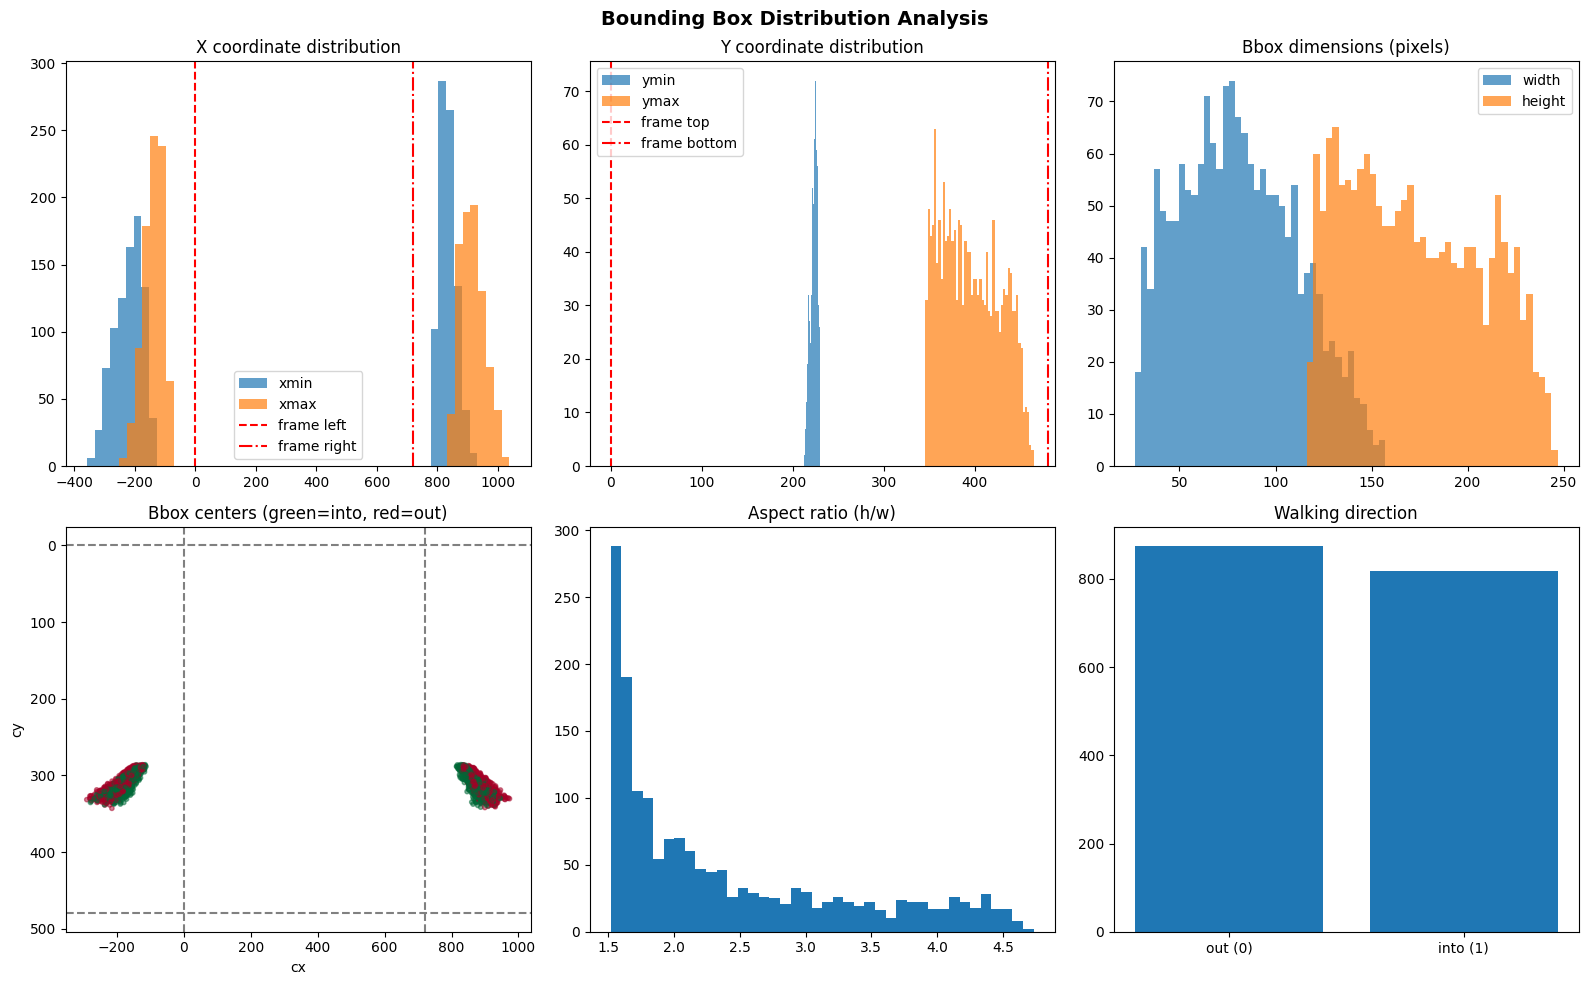

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

axes[0, 0].hist(df["xmin"], bins=50, alpha=0.7, label="xmin")
axes[0, 0].hist(df["xmax"], bins=50, alpha=0.7, label="xmax")
axes[0, 0].axvline(0, color="red", ls="--", label="frame left")
axes[0, 0].axvline(IMG_W, color="red", ls="-.", label="frame right")
axes[0, 0].set_title("X coordinate distribution")
axes[0, 0].legend()

axes[0, 1].hist(df["ymin"], bins=50, alpha=0.7, label="ymin")
axes[0, 1].hist(df["ymax"], bins=50, alpha=0.7, label="ymax")
axes[0, 1].axvline(0, color="red", ls="--", label="frame top")
axes[0, 1].axvline(IMG_H, color="red", ls="-.", label="frame bottom")
axes[0, 1].set_title("Y coordinate distribution")
axes[0, 1].legend()

axes[0, 2].hist(df["bbox_w"], bins=40, alpha=0.7, label="width")
axes[0, 2].hist(df["bbox_h"], bins=40, alpha=0.7, label="height")
axes[0, 2].set_title("Bbox dimensions (pixels)")
axes[0, 2].legend()

axes[1, 0].scatter(df["cx"], df["cy"], c=df["direction"], cmap="RdYlGn",
                   alpha=0.5, s=10)
axes[1, 0].axhline(0, color="gray", ls="--")
axes[1, 0].axhline(IMG_H, color="gray", ls="--")
axes[1, 0].axvline(0, color="gray", ls="--")
axes[1, 0].axvline(IMG_W, color="gray", ls="--")
axes[1, 0].set_title("Bbox centers (green=into, red=out)")
axes[1, 0].set_xlabel("cx")
axes[1, 0].set_ylabel("cy")
axes[1, 0].invert_yaxis()

axes[1, 1].hist(df["aspect_ratio"], bins=40)
axes[1, 1].set_title("Aspect ratio (h/w)")

dir_counts = df["direction"].value_counts().sort_index()
axes[1, 2].bar(["out (0)", "into (1)"], [dir_counts.get(0, 0), dir_counts.get(1, 0)])
axes[1, 2].set_title("Walking direction")

fig.suptitle("Bounding Box Distribution Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "bbox_distributions.png", dpi=120, bbox_inches="tight")
plt.show()

In [17]:
# How far off-screen is the person? (distance from nearest frame edge)
def offscreen_distance(row):
    """Positive = off-screen, negative = inside frame."""
    distances = []
    # Left edge: how far left of x=0
    if row["cx"] < 0:
        distances.append(-row["xmax"])  # positive when fully off-screen
    elif row["cx"] > IMG_W:
        distances.append(row["xmin"] - IMG_W)
    if row["cy"] < 0:
        distances.append(-row["ymax"])
    elif row["cy"] > IMG_H:
        distances.append(row["ymin"] - IMG_H)
    return max(distances) if distances else 0

df["offscreen_dist"] = df.apply(offscreen_distance, axis=1)
print(f"Off-screen distance (px): min={df['offscreen_dist'].min():.1f}  "
      f"mean={df['offscreen_dist'].mean():.1f}  max={df['offscreen_dist'].max():.1f}")
print(f"Persons partially overlapping frame: {(df['offscreen_dist'] < 0).sum()}")

Off-screen distance (px): min=60.6  mean=127.7  max=252.9
Persons partially overlapping frame: 0


## 5. Visualize sample images with their bboxes

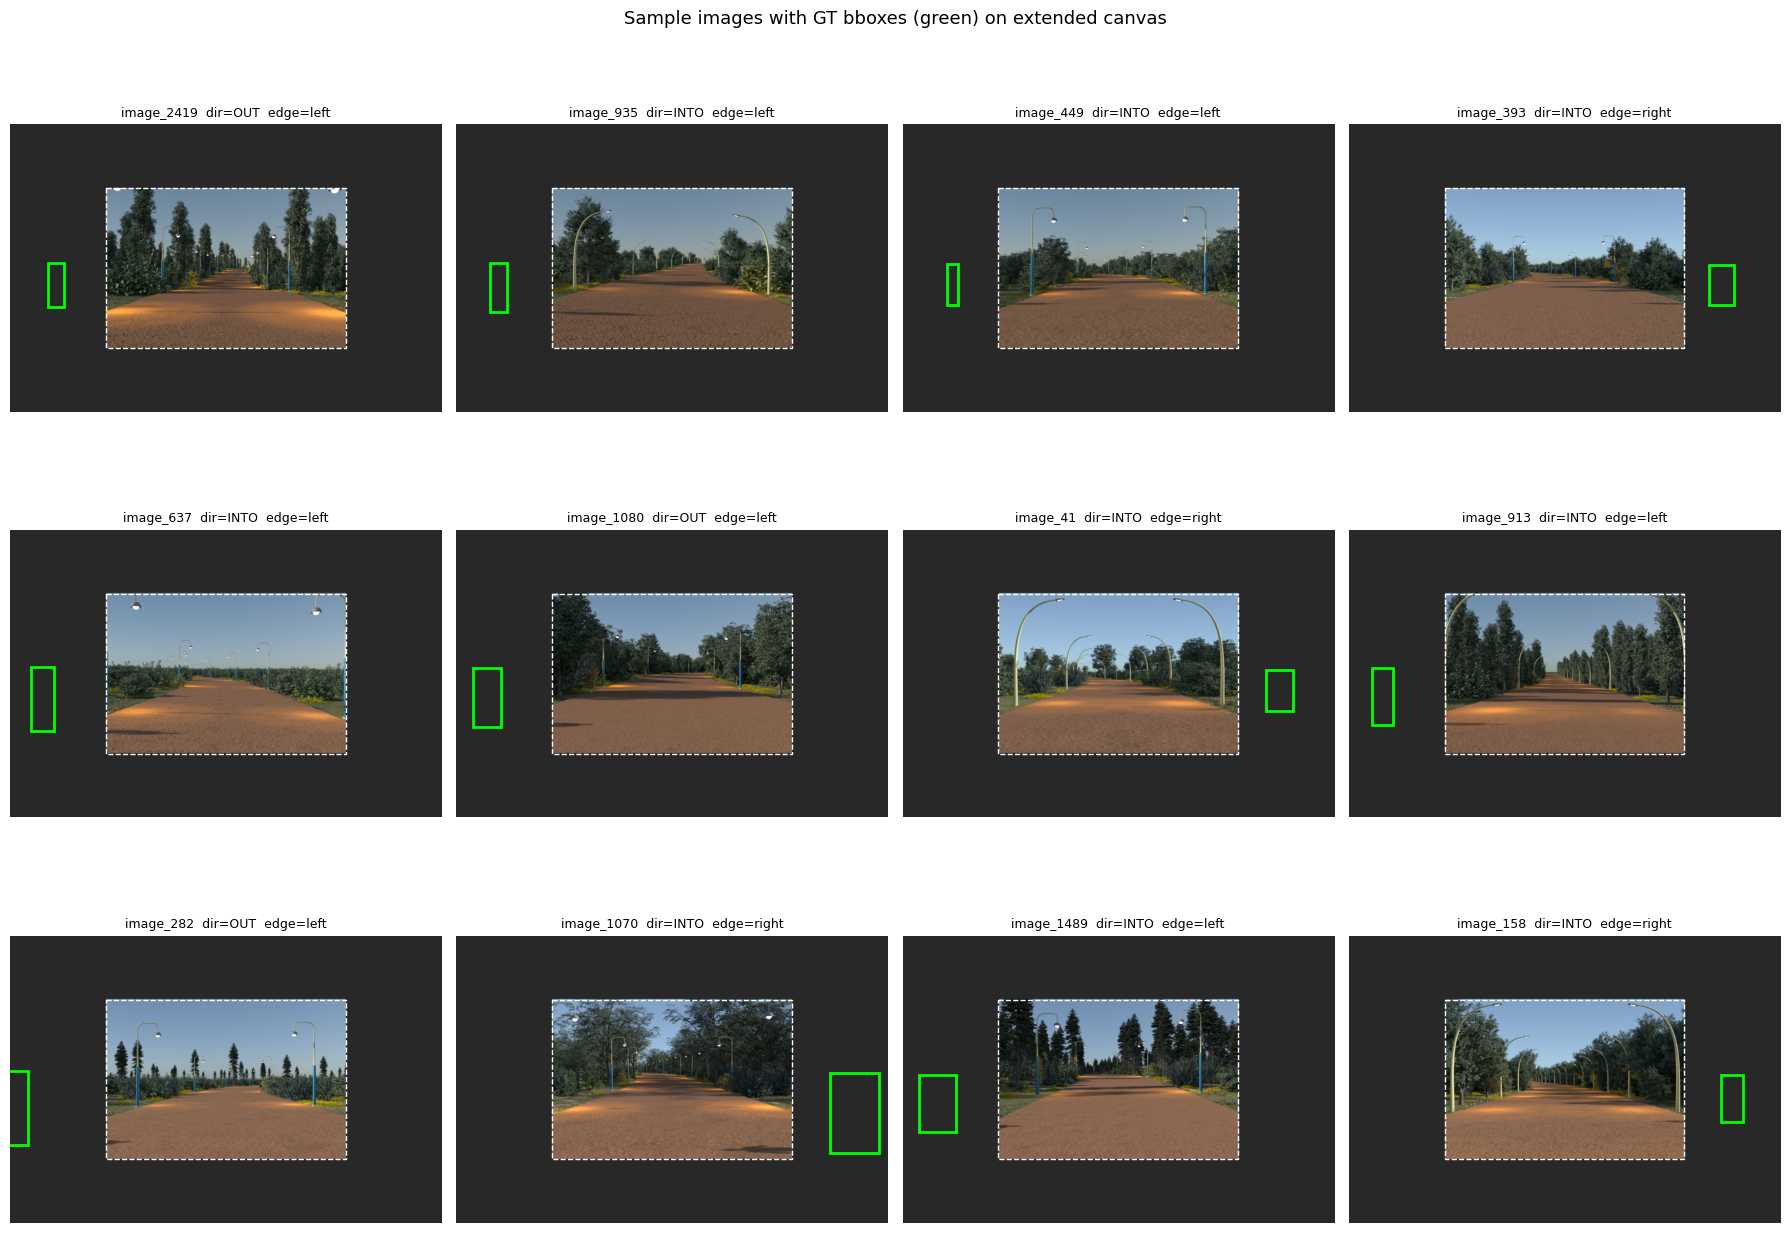

In [18]:
def show_sample(row, ax, pad_ratio=0.4):
    """Draw image with extended canvas showing the off-screen bbox."""
    img = np.asarray(Image.open(row["img_path"]).convert("RGB"))
    h, w = img.shape[:2]
    pad_x = int(w * pad_ratio)
    pad_y = int(h * pad_ratio)

    canvas = np.full((h + 2*pad_y, w + 2*pad_x, 3), 40, dtype=np.uint8)
    canvas[pad_y:pad_y+h, pad_x:pad_x+w] = img

    ax.imshow(canvas)

    # Frame boundary
    frame = patches.Rectangle((pad_x, pad_y), w, h,
                              linewidth=1, edgecolor="white",
                              facecolor="none", linestyle="--")
    ax.add_patch(frame)

    # GT bbox (translated to canvas coords)
    bx1 = row["xmin"] + pad_x
    by1 = row["ymin"] + pad_y
    bw = row["bbox_w"]
    bh = row["bbox_h"]
    rect = patches.Rectangle((bx1, by1), bw, bh,
                             linewidth=2, edgecolor="lime",
                             facecolor="none")
    ax.add_patch(rect)

    dir_str = "INTO" if row["direction"] == 1 else "OUT"
    ax.set_title(f"{row['stem']}  dir={dir_str}  edge={row['edge']}", fontsize=9)
    ax.axis("off")


# Show a grid of samples, picking from different edges
n_show = min(12, len(df))
sample_rows = df.sample(n=n_show, random_state=42).reset_index(drop=True)

cols = 4
rows_grid = (n_show + cols - 1) // cols
fig, axes = plt.subplots(rows_grid, cols, figsize=(18, 4.5 * rows_grid))
axes = axes.flatten()

for i in range(n_show):
    show_sample(sample_rows.iloc[i], axes[i])
for i in range(n_show, len(axes)):
    axes[i].axis("off")

plt.suptitle("Sample images with GT bboxes (green) on extended canvas", fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "sample_images.png", dpi=120, bbox_inches="tight")
plt.show()

Samples per edge type:
  left: 852 samples
  right: 840 samples


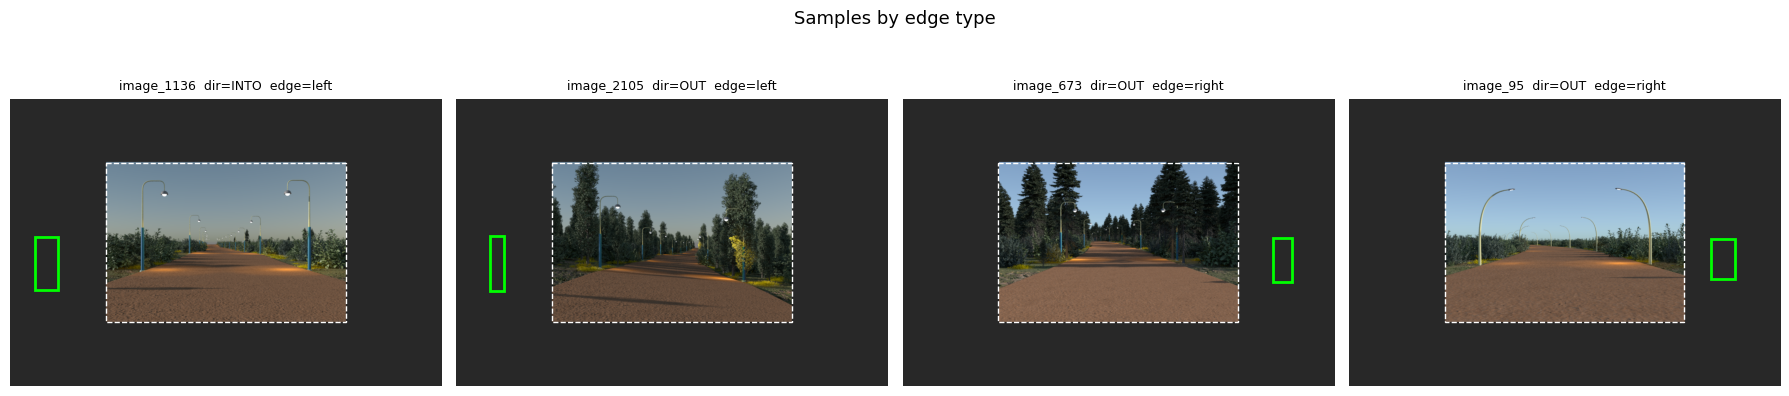

In [19]:
# Show a few from each edge type
print("Samples per edge type:")
for edge_type in df["edge"].unique():
    subset = df[df["edge"] == edge_type]
    print(f"  {edge_type}: {len(subset)} samples")

# Pick 2 from each edge type
fig_rows = []
for edge_type in sorted(df["edge"].unique()):
    subset = df[df["edge"] == edge_type]
    fig_rows.extend(subset.sample(n=min(2, len(subset)), random_state=42).index.tolist())

n_edge = len(fig_rows)
if n_edge > 0:
    cols = min(4, n_edge)
    rows_g = (n_edge + cols - 1) // cols
    fig, axes = plt.subplots(rows_g, cols, figsize=(18, 4.5 * rows_g))
    if n_edge == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
    for i, idx in enumerate(fig_rows):
        show_sample(df.iloc[idx], axes[i])
    for i in range(n_edge, len(axes)):
        axes[i].axis("off")
    plt.suptitle("Samples by edge type", fontsize=13)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "edge_samples.png", dpi=120, bbox_inches="tight")
    plt.show()

## 6. Shadow characteristics

In [20]:
# Analyze shadow properties in a few images:
# - Where in the frame is the shadow?
# - How does shadow position correlate with person position?

shadow_stats = []
sample_idx = np.linspace(0, len(df)-1, min(50, len(df)), dtype=int)

for i in sample_idx:
    row = df.iloc[i]
    img = np.asarray(Image.open(row["img_path"]).convert("RGB"))

    # Quick shadow detection: dark pixels in L channel
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB).astype(np.float32)
    L = lab[:, :, 0]
    L_u8 = np.clip(L, 0, 255).astype(np.uint8)
    otsu_thr, binary = cv2.threshold(L_u8, 0, 255,
                                      cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    shadow_mask = binary > 0
    shadow_pixels = np.column_stack(np.where(shadow_mask))

    if len(shadow_pixels) > 10:
        shadow_cy = shadow_pixels[:, 0].mean()
        shadow_cx = shadow_pixels[:, 1].mean()
        shadow_area_ratio = shadow_mask.mean()
    else:
        shadow_cy = shadow_cx = shadow_area_ratio = float("nan")

    shadow_stats.append({
        "stem": row["stem"],
        "person_cx": row["cx"],
        "person_cy": row["cy"],
        "shadow_cx": shadow_cx,
        "shadow_cy": shadow_cy,
        "shadow_area": shadow_area_ratio,
        "otsu_thr": float(otsu_thr),
        "direction": row["direction"],
    })

shadow_df = pd.DataFrame(shadow_stats).dropna()
print(f"Shadow analysis on {len(shadow_df)} images:")
print(f"  Shadow area ratio: {shadow_df['shadow_area'].mean():.3f} +/- {shadow_df['shadow_area'].std():.3f}")
print(f"  Otsu threshold: {shadow_df['otsu_thr'].mean():.1f} +/- {shadow_df['otsu_thr'].std():.1f}")

Shadow analysis on 50 images:
  Shadow area ratio: 0.477 +/- 0.118
  Otsu threshold: 109.3 +/- 27.1


KeyError: 'x'

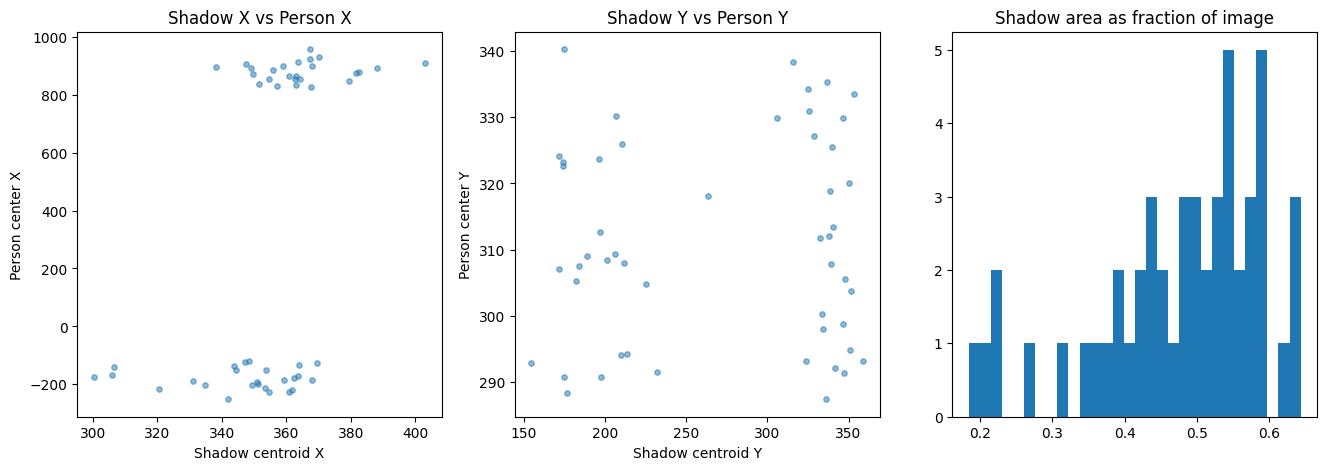

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].scatter(shadow_df["shadow_cx"], shadow_df["person_cx"],
               alpha=0.5, s=15)
axes[0].set_xlabel("Shadow centroid X")
axes[0].set_ylabel("Person center X")
axes[0].set_title("Shadow X vs Person X")

axes[1].scatter(shadow_df["shadow_cy"], shadow_df["person_cy"],
               alpha=0.5, s=15)
axes[1].set_xlabel("Shadow centroid Y")
axes[1].set_ylabel("Person center Y")
axes[1].set_title("Shadow Y vs Person Y")

axes[2].hist(shadow_df["shadow_area"], bins=30)
axes[2].set_title("Shadow area as fraction of image")

for ax in axes[:2]:
    corr = np.corrcoef(
        shadow_df[ax.get_xlabel().split()[-1].lower()].values,
        shadow_df[ax.get_ylabel().split()[-1].lower()].values
    )[0, 1] if len(shadow_df) > 2 else 0

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "shadow_vs_person.png", dpi=120, bbox_inches="tight")
plt.show()

# Correlation
if len(shadow_df) > 5:
    print("Correlations (shadow centroid vs person center):")
    print(f"  X: r={shadow_df['shadow_cx'].corr(shadow_df['person_cx']):.3f}")
    print(f"  Y: r={shadow_df['shadow_cy'].corr(shadow_df['person_cy']):.3f}")

## 7. Direction analysis

Direction distribution:
direction
0    874
1    818

Balance: 48.3% walking into frame

Direction by edge:


,out_of_frame,into_frame
edge,,
left,430,422
right,444,396


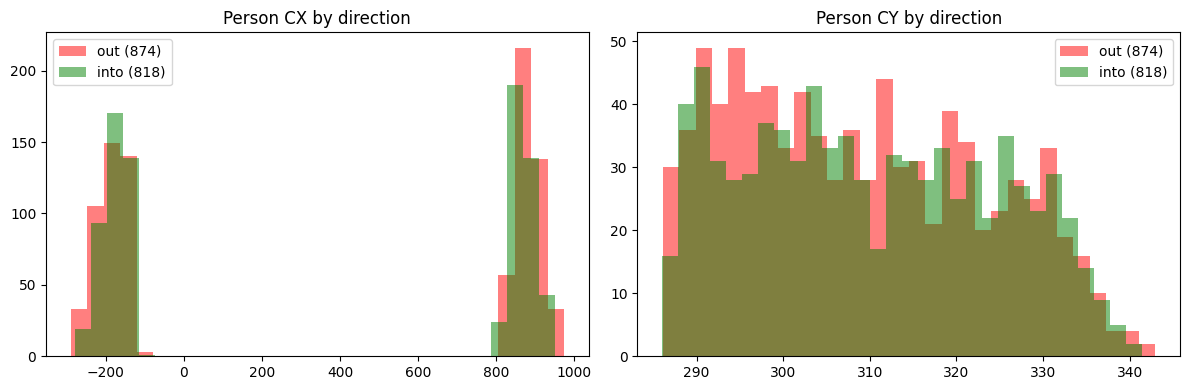

In [22]:
print("Direction distribution:")
print(df["direction"].value_counts().to_string())
print(f"\nBalance: {df['direction'].mean()*100:.1f}% walking into frame")

# Direction vs edge
print("\nDirection by edge:")
ct = pd.crosstab(df["edge"], df["direction"])
ct.columns = ["out_of_frame", "into_frame"]
display(ct)

# Direction vs person X position
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for d, label, color in [(0, "out", "red"), (1, "into", "green")]:
    sub = df[df["direction"] == d]
    axes[0].hist(sub["cx"], bins=30, alpha=0.5, label=f"{label} ({len(sub)})", color=color)
    axes[1].hist(sub["cy"], bins=30, alpha=0.5, label=f"{label} ({len(sub)})", color=color)
axes[0].set_title("Person CX by direction")
axes[1].set_title("Person CY by direction")
for ax in axes:
    ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "direction_analysis.png", dpi=120, bbox_inches="tight")
plt.show()

## 8. Critical checks for the model

In [23]:
print("=== CRITICAL INFO FOR MODEL DESIGN ===")
print()
print(f"1. Image size: {IMG_W} x {IMG_H}")
print(f"2. Number of training samples: {len(df)}")
print(f"3. All bboxes axis-aligned: {is_rect.all()}")
print()
print(f"4. Normalized bbox ranges (these define the output space):")
print(f"   xmin_norm: [{df['xmin_norm'].min():.3f}, {df['xmin_norm'].max():.3f}]")
print(f"   ymin_norm: [{df['ymin_norm'].min():.3f}, {df['ymin_norm'].max():.3f}]")
print(f"   xmax_norm: [{df['xmax_norm'].min():.3f}, {df['xmax_norm'].max():.3f}]")
print(f"   ymax_norm: [{df['ymax_norm'].min():.3f}, {df['ymax_norm'].max():.3f}]")
print()
print(f"5. Bbox size (normalized):")
print(f"   width:  [{df['bbox_w_norm'].min():.3f}, {df['bbox_w_norm'].max():.3f}] mean={df['bbox_w_norm'].mean():.3f}")
print(f"   height: [{df['bbox_h_norm'].min():.3f}, {df['bbox_h_norm'].max():.3f}] mean={df['bbox_h_norm'].mean():.3f}")
print()
print(f"6. Direction balance: {df['direction'].mean()*100:.1f}% into frame")
print(f"7. Edge distribution:")
for edge, count in df["edge"].value_counts().items():
    print(f"   {edge}: {count} ({count/len(df)*100:.1f}%)")
print()
print(f"8. Persons partially overlapping frame: {(df['offscreen_dist'] < 0).sum()}")
print(f"9. Test set size: {len(test_pngs)}")

=== CRITICAL INFO FOR MODEL DESIGN ===

1. Image size: 720 x 480
2. Number of training samples: 1692
3. All bboxes axis-aligned: True

4. Normalized bbox ranges (these define the output space):
   xmin_norm: [-0.499, 1.296]
   ymin_norm: [0.441, 0.480]
   xmax_norm: [-0.351, 1.443]
   ymax_norm: [0.720, 0.968]

5. Bbox size (normalized):
   width:  [0.037, 0.218] mean=0.112
   height: [0.243, 0.514] mean=0.360

6. Direction balance: 48.3% into frame
7. Edge distribution:
   left: 852 (50.4%)
   right: 840 (49.6%)

8. Persons partially overlapping frame: 0
9. Test set size: 414


## 9. Export CSVs for pipeline

In [24]:
# Full annotation table
export_cols = [
    "stem", "img_path", "direction", "edge",
    "xmin", "ymin", "xmax", "ymax",
    "bbox_w", "bbox_h", "cx", "cy",
    "xmin_norm", "ymin_norm", "xmax_norm", "ymax_norm",
    "bbox_w_norm", "bbox_h_norm", "cx_norm", "cy_norm",
    "aspect_ratio", "offscreen_dist",
]
df[export_cols].to_csv(OUTPUT_DIR / "train_annotations_parsed.csv", index=False)
print(f"Saved train_annotations_parsed.csv ({len(df)} rows, {len(export_cols)} cols)")

Saved train_annotations_parsed.csv (1692 rows, 22 cols)


In [25]:
# Summary statistics as a small CSV (easy to paste into chat)
summary = {
    "img_w": IMG_W,
    "img_h": IMG_H,
    "n_train": len(df),
    "n_test": len(test_pngs),
    "all_axis_aligned": bool(is_rect.all()),
    "direction_pct_into": round(df["direction"].mean() * 100, 1),
    "xmin_norm_min": round(df["xmin_norm"].min(), 4),
    "xmin_norm_max": round(df["xmin_norm"].max(), 4),
    "ymin_norm_min": round(df["ymin_norm"].min(), 4),
    "ymin_norm_max": round(df["ymin_norm"].max(), 4),
    "xmax_norm_min": round(df["xmax_norm"].min(), 4),
    "xmax_norm_max": round(df["xmax_norm"].max(), 4),
    "ymax_norm_min": round(df["ymax_norm"].min(), 4),
    "ymax_norm_max": round(df["ymax_norm"].max(), 4),
    "bbox_w_norm_mean": round(df["bbox_w_norm"].mean(), 4),
    "bbox_h_norm_mean": round(df["bbox_h_norm"].mean(), 4),
    "aspect_ratio_mean": round(df["aspect_ratio"].mean(), 2),
}
summary_df = pd.DataFrame([summary])
summary_df.to_csv(OUTPUT_DIR / "dataset_summary.csv", index=False)
print("Saved dataset_summary.csv")
print()
for k, v in summary.items():
    print(f"  {k}: {v}")

Saved dataset_summary.csv

  img_w: 720
  img_h: 480
  n_train: 1692
  n_test: 414
  all_axis_aligned: True
  direction_pct_into: 48.3
  xmin_norm_min: -0.4987
  xmin_norm_max: 1.2958
  ymin_norm_min: 0.4414
  ymin_norm_max: 0.4798
  xmax_norm_min: -0.3512
  xmax_norm_max: 1.4427
  ymax_norm_min: 0.72
  ymax_norm_max: 0.9676
  bbox_w_norm_mean: 0.1123
  bbox_h_norm_mean: 0.3602
  aspect_ratio_mean: 2.4


In [26]:
# Edge type distribution CSV
edge_dist = df["edge"].value_counts().reset_index()
edge_dist.columns = ["edge_type", "count"]
edge_dist["pct"] = (edge_dist["count"] / len(df) * 100).round(1)
edge_dist.to_csv(OUTPUT_DIR / "edge_distribution.csv", index=False)
print("Saved edge_distribution.csv")
display(edge_dist)

Saved edge_distribution.csv


,edge_type,count,pct
0,left,852,50.4
1,right,840,49.6


## 10. Quick look at test images

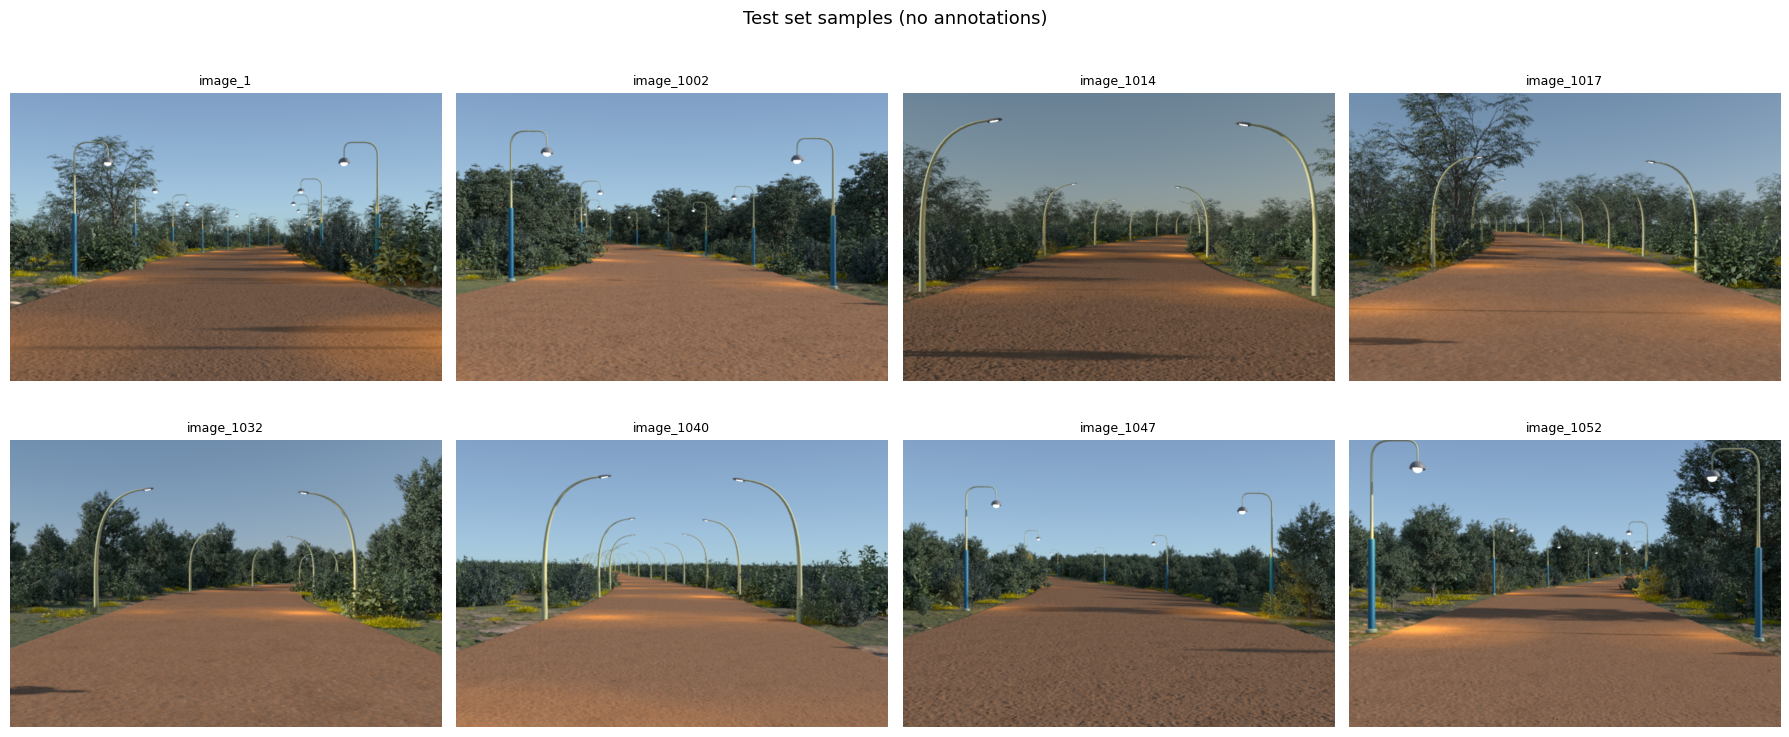

In [27]:
if test_pngs:
    n_show_test = min(8, len(test_pngs))
    fig, axes = plt.subplots(2, 4, figsize=(18, 8))
    axes = axes.flatten()
    test_sample = sorted(test_pngs)[:n_show_test]
    for i, p in enumerate(test_sample):
        img = np.asarray(Image.open(p).convert("RGB"))
        axes[i].imshow(img)
        axes[i].set_title(p.stem, fontsize=9)
        axes[i].axis("off")
    for i in range(n_show_test, len(axes)):
        axes[i].axis("off")
    plt.suptitle("Test set samples (no annotations)", fontsize=13)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "test_samples.png", dpi=120, bbox_inches="tight")
    plt.show()
else:
    print("No test images found.")

## 11. Sanity check: verify IoU computation matches competition

If we just predict the **mean bbox** for every image, what IoU do we get?

In [28]:
def compute_iou(box1, box2):
    """box format: [xmin, ymin, xmax, ymax]"""
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])
    inter = max(0, x2 - x1) * max(0, y2 - y1)
    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union = area1 + area2 - inter
    return inter / (union + 1e-7)


# Baseline 1: predict mean bbox for everything
mean_box = [df["xmin"].mean(), df["ymin"].mean(),
            df["xmax"].mean(), df["ymax"].mean()]
ious_mean = []
for _, row in df.iterrows():
    gt = [row["xmin"], row["ymin"], row["xmax"], row["ymax"]]
    ious_mean.append(compute_iou(mean_box, gt))

print(f"Baseline: predict MEAN bbox for all images")
print(f"  Mean box: {[round(v, 1) for v in mean_box]}")
print(f"  Mean IoU: {np.mean(ious_mean):.4f}")
print(f"  Median IoU: {np.median(ious_mean):.4f}")

# Baseline 2: predict median bbox
median_box = [df["xmin"].median(), df["ymin"].median(),
              df["xmax"].median(), df["ymax"].median()]
ious_median = []
for _, row in df.iterrows():
    gt = [row["xmin"], row["ymin"], row["xmax"], row["ymax"]]
    ious_median.append(compute_iou(median_box, gt))

print(f"\nBaseline: predict MEDIAN bbox for all images")
print(f"  Median box: {[round(v, 1) for v in median_box]}")
print(f"  Mean IoU: {np.mean(ious_median):.4f}")

# Baseline 3: per-edge mean
print(f"\nBaseline: predict MEAN bbox per edge type")
ious_edge = []
for _, row in df.iterrows():
    edge_sub = df[df["edge"] == row["edge"]]
    edge_box = [edge_sub["xmin"].mean(), edge_sub["ymin"].mean(),
                edge_sub["xmax"].mean(), edge_sub["ymax"].mean()]
    gt = [row["xmin"], row["ymin"], row["xmax"], row["ymax"]]
    ious_edge.append(compute_iou(edge_box, gt))
print(f"  Mean IoU: {np.mean(ious_edge):.4f}")

print(f"\nThese baselines tell us what score a random/constant prediction gets.")
print(f"The CNN model should beat all of these significantly.")

Baseline: predict MEAN bbox for all images
  Mean box: [np.float64(303.5), np.float64(222.9), np.float64(384.4), np.float64(395.8)]
  Mean IoU: 0.0000
  Median IoU: 0.0000

Baseline: predict MEDIAN bbox for all images
  Median box: [np.float64(-135.9), np.float64(223.5), np.float64(-83.1), np.float64(392.7)]
  Mean IoU: 0.0510

Baseline: predict MEAN bbox per edge type
  Mean IoU: 0.4295

These baselines tell us what score a random/constant prediction gets.
The CNN model should beat all of these significantly.


## 12. Final notes for pipeline design

After running this notebook, check:

1. **JSON format**: bbox corners are `[x, y]` arrays under a `"bbox"` key -- pipeline.py must match this
2. **Coordinate ranges**: what are the actual min/max for normalized coords? This tells us if the model output space is reasonable
3. **Edge distribution**: if heavily skewed to one side, consider data augmentation (horizontal flip)
4. **Direction balance**: if imbalanced, consider weighted BCE loss
5. **Image size**: if large, 224px resize may lose shadow detail -- consider 384 or 448
6. **Baseline IoU**: this is the floor the model must beat

In [29]:
print("=" * 60)
print("COPY THIS BLOCK AND PASTE IT TO CLAUDE FOR PIPELINE TUNING")
print("=" * 60)
print(f"img_size: {IMG_W}x{IMG_H}")
print(f"n_train: {len(df)}")
print(f"n_test: {len(test_pngs)}")
print(f"axis_aligned: {bool(is_rect.all())}")
print(f"direction_balance: {df['direction'].mean()*100:.1f}% into")
print(f"edge_distribution: {df['edge'].value_counts().to_dict()}")
print(f"xmin_norm range: [{df['xmin_norm'].min():.4f}, {df['xmin_norm'].max():.4f}]")
print(f"ymin_norm range: [{df['ymin_norm'].min():.4f}, {df['ymin_norm'].max():.4f}]")
print(f"xmax_norm range: [{df['xmax_norm'].min():.4f}, {df['xmax_norm'].max():.4f}]")
print(f"ymax_norm range: [{df['ymax_norm'].min():.4f}, {df['ymax_norm'].max():.4f}]")
print(f"bbox_w_norm: mean={df['bbox_w_norm'].mean():.4f} std={df['bbox_w_norm'].std():.4f}")
print(f"bbox_h_norm: mean={df['bbox_h_norm'].mean():.4f} std={df['bbox_h_norm'].std():.4f}")
print(f"aspect_ratio: mean={df['aspect_ratio'].mean():.2f} std={df['aspect_ratio'].std():.2f}")
print(f"baseline_mean_iou: {np.mean(ious_mean):.4f}")
print(f"baseline_median_iou: {np.mean(ious_median):.4f}")
print(f"baseline_per_edge_iou: {np.mean(ious_edge):.4f}")
print(f"channel_means_rgb: {mean_vals.mean(axis=0).tolist()}")
print(f"channel_stds_rgb: {std_vals.mean(axis=0).tolist()}")
print(f"json_format: bbox.top_left=[x,y] (list, not dict)")

COPY THIS BLOCK AND PASTE IT TO CLAUDE FOR PIPELINE TUNING
img_size: 720x480
n_train: 1692
n_test: 414
axis_aligned: True
direction_balance: 48.3% into
edge_distribution: {'left': 852, 'right': 840}
xmin_norm range: [-0.4987, 1.2958]
ymin_norm range: [0.4414, 0.4798]
xmax_norm range: [-0.3512, 1.4427]
ymax_norm range: [0.7200, 0.9676]
bbox_w_norm: mean=0.1123 std=0.0415
bbox_h_norm: mean=0.3602 std=0.0723
aspect_ratio: mean=2.40 std=0.90
baseline_mean_iou: 0.0000
baseline_median_iou: 0.0510
baseline_per_edge_iou: 0.4295
channel_means_rgb: [0.4364286959171295, 0.4325997829437256, 0.4185255169868469]
channel_stds_rgb: [0.1614415943622589, 0.17531155049800873, 0.239155575633049]
json_format: bbox.top_left=[x,y] (list, not dict)
